# Phishing Website Detection - Reproduction Study

This notebook reproduces and evaluates the GitHub project "URL-Based Phishing Detection Using Machine Learning".

The goal is to verify the author's findings, examine the dataset, evaluate the preprocessing steps, and reproduce the machine learning results.

In [1]:
import pandas as pd

df = pd.read_csv("phishing.csv")
df.head()

,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


## Data Loading and Initial Inspection

In [2]:
import pandas as pd

df = pd.read_csv("phishing.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (11054, 32)


,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


## Dataset Information

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (11054, 32)

Column Names:
['Index', 'UsingIP', 'LongURL', 'ShortURL', 'Symbol@', 'Redirecting//', 'PrefixSuffix-', 'SubDomains', 'HTTPS', 'DomainRegLen', 'Favicon', 'NonStdPort', 'HTTPSDomainURL', 'RequestURL', 'AnchorURL', 'LinksInScriptTags', 'ServerFormHandler', 'InfoEmail', 'AbnormalURL', 'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick', 'UsingPopupWindow', 'IframeRedirection', 'AgeofDomain', 'DNSRecording', 'WebsiteTraffic', 'PageRank', 'GoogleIndex', 'LinksPointingToPage', 'StatsReport', 'class']

Data Types:
Index                  int64
UsingIP                int64
LongURL                int64
ShortURL               int64
Symbol@                int64
Redirecting//          int64
PrefixSuffix-          int64
SubDomains             int64
HTTPS                  int64
DomainRegLen           int64
Favicon                int64
NonStdPort             int64
HTTPSDomainURL         int64
RequestURL             int64
AnchorURL              int64
LinksInScriptTags  

### Dataset Structure Analysis

The dataset contains 11,054 observations and 32 columns. All features are stored as integer values, indicating that no additional encoding is required before model training.

The column named "Index" appears to function only as a row identifier rather than a meaningful cybersecurity feature. Since it does not contain predictive information about whether a website is phishing or legitimate, it should be removed before model training to avoid introducing unnecessary noise into the analysis.

In [4]:
df = df.drop("Index", axis=1)

print("Dataset Shape After Removing Index:", df.shape)

Dataset Shape After Removing Index: (11054, 31)


## Missing Values and Duplicate Records

This section checks whether the dataset contains missing values or duplicate rows before model training.

In [5]:
missing_values = df.isnull().sum()
missing_values

UsingIP                0
LongURL                0
ShortURL               0
Symbol@                0
Redirecting//          0
PrefixSuffix-          0
SubDomains             0
HTTPS                  0
DomainRegLen           0
Favicon                0
NonStdPort             0
HTTPSDomainURL         0
RequestURL             0
AnchorURL              0
LinksInScriptTags      0
ServerFormHandler      0
InfoEmail              0
AbnormalURL            0
WebsiteForwarding      0
StatusBarCust          0
DisableRightClick      0
UsingPopupWindow       0
IframeRedirection      0
AgeofDomain            0
DNSRecording           0
WebsiteTraffic         0
PageRank               0
GoogleIndex            0
LinksPointingToPage    0
StatsReport            0
class                  0
dtype: int64

In [6]:
duplicate_rows = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 5205


In [7]:
print("Shape before removing duplicates:", df.shape)

df_no_dup = df.drop_duplicates()

print("Shape after removing duplicates:", df_no_dup.shape)

print("Duplicates removed:", df.shape[0] - df_no_dup.shape[0])

Shape before removing duplicates: (11054, 31)
Shape after removing duplicates: (5849, 31)
Duplicates removed: 5205


## Missing Values Analysis

In [8]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


## Duplicate Analysis

In [9]:
duplicates = df.duplicated().sum()

print("Dataset Shape Before Removing Duplicates:", df.shape)
print("Number of Duplicate Rows:", duplicates)

df_no_dup = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df_no_dup.shape)

Dataset Shape Before Removing Duplicates: (11054, 31)
Number of Duplicate Rows: 5205
Dataset Shape After Removing Duplicates: (5849, 31)


## Duplicate Pattern Analysis

Although exact duplicate rows were removed during preprocessing, it is possible for multiple observations to share identical feature values while having different class labels. This analysis examines repeated feature patterns and identifies whether contradictory labels exist within the dataset. Such patterns can lead to optimistic performance estimates if similar observations appear in both the training and testing sets.

In [19]:
# Identify feature columns (exclude Index and target class)
feature_cols = [col for col in df.columns if col not in ["Index", "class"]]

# Count unique feature patterns
pattern_counts = (
    df.groupby(feature_cols)
      .size()
      .reset_index(name="count")
)

print("Number of unique feature patterns:", pattern_counts.shape[0])
print("Number of repeated feature patterns:", (pattern_counts["count"] > 1).sum())

# Check whether identical feature patterns have different labels
label_counts_per_pattern = (
    df.groupby(feature_cols)["class"]
      .nunique()
      .reset_index(name="num_labels")
)

contradictory_patterns = label_counts_per_pattern[
    label_counts_per_pattern["num_labels"] > 1
]

print("Number of contradictory feature patterns:", contradictory_patterns.shape[0])

# Show first few contradictory patterns if any exist
contradictory_patterns.head()

Number of unique feature patterns: 5785
Number of repeated feature patterns: 2614
Number of contradictory feature patterns: 64


,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,Favicon,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,num_labels
1061,-1,-1,1,1,1,-1,-1,1,-1,1,...,1,1,-1,1,0,1,1,0,1,2
1306,-1,-1,1,1,1,-1,0,-1,1,1,...,1,1,-1,1,1,-1,1,1,1,2
1308,-1,-1,1,1,1,-1,0,-1,1,1,...,1,1,-1,1,1,1,1,1,1,2
1325,-1,-1,1,1,1,-1,0,-1,1,1,...,1,1,-1,1,1,-1,1,1,1,2
1477,-1,-1,1,1,1,-1,0,1,-1,1,...,1,1,-1,1,1,-1,1,0,1,2


### Interpretation

The analysis revealed 5,785 unique feature patterns and 2,614 repeated feature patterns within the dataset. More importantly, 64 feature patterns were associated with both phishing and legitimate labels.

This finding indicates that identical website feature combinations do not always correspond to a single class label. Such contradictory patterns may reflect labeling inconsistencies, noise in the dataset, or limitations in the selected feature set. From a machine learning perspective, these observations increase classification difficulty because identical inputs may correspond to different outputs.

In addition, repeated feature patterns raise the possibility that highly similar observations may appear in both the training and testing sets during a standard random split. This can lead to overly optimistic performance estimates because the model may encounter nearly identical patterns during training and evaluation.

To investigate this issue further, a group-aware train-test split was evaluated later in the analysis.

## Group-Aware Train-Test Split

Because many repeated feature patterns were identified in the dataset, a standard random train-test split may allow identical patterns to appear in both the training and testing sets. This can lead to optimistic performance estimates. To evaluate this possibility, a group-aware split was performed in which identical feature patterns were forced to remain entirely within either the training set or the testing set.

In [20]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
)

# Use the dataset after duplicate removal
feature_cols = [col for col in df_no_dup.columns if col != "class"]

X_group = df_no_dup[feature_cols]
y_group = df_no_dup["class"]

# Create a unique group ID for each feature pattern
groups = X_group.astype(str).agg("_".join, axis=1)

# Group-aware split
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X_group, y_group, groups=groups)
)

X_train_group = X_group.iloc[train_idx]
X_test_group = X_group.iloc[test_idx]

y_train_group = y_group.iloc[train_idx]
y_test_group = y_group.iloc[test_idx]

# Train Gradient Boosting
gb_group = GradientBoostingClassifier(
    max_depth=4,
    learning_rate=0.7,
    random_state=42
)

gb_group.fit(X_train_group, y_train_group)

y_pred_group = gb_group.predict(X_test_group)

print("Group-Aware Split Results")
print("-------------------------")
print("Accuracy:", accuracy_score(y_test_group, y_pred_group))
print("Precision:", precision_score(y_test_group, y_pred_group, pos_label=1))
print("Recall:", recall_score(y_test_group, y_pred_group, pos_label=1))
print("F1 Score:", f1_score(y_test_group, y_pred_group, pos_label=1))
print("MCC:", matthews_corrcoef(y_test_group, y_pred_group))

Group-Aware Split Results
-------------------------
Accuracy: 0.9521367521367521
Precision: 0.9530201342281879
Recall: 0.9530201342281879
F1 Score: 0.9530201342281879
MCC: 0.9042396464233099


### Interpretation

The group-aware split produced an accuracy of 95.21%, which is slightly higher than the 94.62% obtained using the standard random train-test split. Precision, Recall, F1-score, and MCC also remained very strong.

These results suggest that the model's performance is not primarily driven by duplicate-pattern leakage. Even when identical feature patterns were prevented from appearing in both the training and testing sets, the classifier maintained excellent predictive performance.

Therefore, while duplicate patterns and contradictory labels exist within the dataset, the overall conclusions regarding the effectiveness of the Gradient Boosting model remain unchanged.

## Class Distribution Analysis

In [16]:
class_counts = df_no_dup['class'].value_counts()

print(class_counts)

class
-1    3019
 1    2830
Name: count, dtype: int64


In [17]:
class_percentages = df_no_dup['class'].value_counts(normalize=True) * 100

print(class_percentages)

class
-1    51.615661
 1    48.384339
Name: proportion, dtype: float64


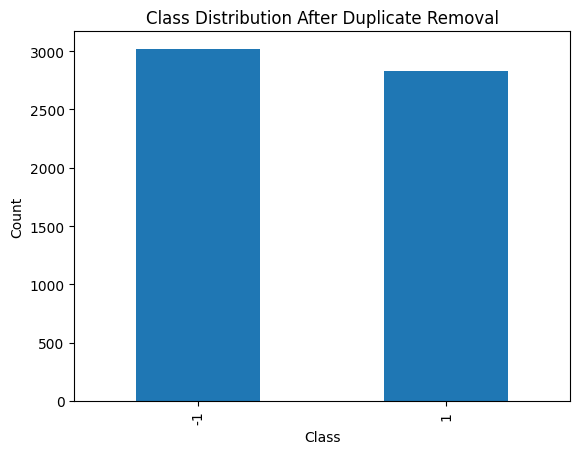

In [15]:
import matplotlib.pyplot as plt

class_counts.plot(kind='bar')

plt.title("Class Distribution After Duplicate Removal")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## Crosstab Analysis

In [38]:
print("HTTPS vs Class")
print(pd.crosstab(df["HTTPS"], df["class"]))

print("\nAnchorURL vs Class")
print(pd.crosstab(df["AnchorURL"], df["class"]))

print("\nWebsiteTraffic vs Class")
print(pd.crosstab(df["WebsiteTraffic"], df["class"]))

HTTPS vs Class
class    -1     1
HTTPS            
-1     3050   506
 0     1146    21
 1      701  5630

AnchorURL vs Class
class        -1     1
AnchorURL            
-1         3245    36
 0         1502  3835
 1          150  2286

WebsiteTraffic vs Class
class             -1     1
WebsiteTraffic            
-1              1672   982
 0              1718   851
 1              1507  4324


The crosstab analysis revealed clear differences in the distributions of HTTPS, AnchorURL, and WebsiteTraffic between phishing and legitimate websites. Legitimate websites were more likely to exhibit favorable values for these features, while phishing websites were concentrated in suspicious categories. These findings support the correlation analysis and further demonstrate the predictive value of these variables.

## Correlation Analysis

In [39]:
correlations = df_no_dup.corr()['class'].sort_values(ascending=False)

print(correlations)

class                  1.000000
HTTPS                  0.693228
AnchorURL              0.679125
PrefixSuffix-          0.381134
SubDomains             0.296214
WebsiteTraffic         0.281709
ServerFormHandler      0.281131
LinksInScriptTags      0.243864
RequestURL             0.237778
GoogleIndex            0.118217
StatsReport            0.108486
UsingIP                0.104952
LinksPointingToPage    0.068463
AgeofDomain            0.062800
LongURL                0.058228
PageRank               0.048140
Symbol@                0.034757
DNSRecording           0.033204
NonStdPort             0.014201
StatusBarCust          0.012790
DisableRightClick      0.009286
InfoEmail             -0.008014
IframeRedirection     -0.011756
UsingPopupWindow      -0.022455
Favicon               -0.025457
Redirecting//         -0.036693
WebsiteForwarding     -0.037462
HTTPSDomainURL        -0.051412
ShortURL              -0.076166
AbnormalURL           -0.090043
DomainRegLen          -0.218623
Name: cl

In [40]:
print(correlations.head(10))

class                1.000000
HTTPS                0.693228
AnchorURL            0.679125
PrefixSuffix-        0.381134
SubDomains           0.296214
WebsiteTraffic       0.281709
ServerFormHandler    0.281131
LinksInScriptTags    0.243864
RequestURL           0.237778
GoogleIndex          0.118217
Name: class, dtype: float64


## Top Feature Correlations

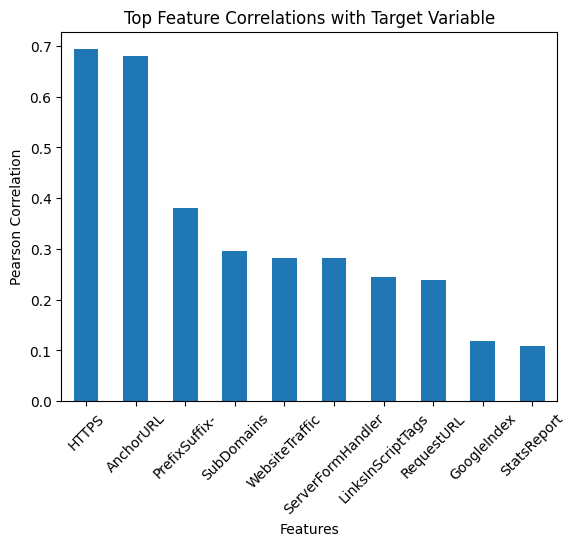

In [41]:
import matplotlib.pyplot as plt

top_features = correlations.drop('class').head(10)

top_features.plot(kind='bar')

plt.title("Top Feature Correlations with Target Variable")
plt.xlabel("Features")
plt.ylabel("Pearson Correlation")
plt.xticks(rotation=45)

plt.show()

## Feature Distributions

In [42]:
df_no_dup.describe()

,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,Favicon,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
count,5849.000000,5849.000000,5849.000000,5849.000000,5849.000000,5849.000000,5849.000000,5849.000000,5849.000000,5849.000000,...,5849.000000,5849.000000,5849.000000,5849.000000,5849.000000,5849.000000,5849.000000,5849.000000,5849.000000,5849.000000
mean,0.132843,-0.616003,0.720294,0.588648,0.718242,-0.760301,0.065823,0.149085,-0.305864,0.581809,...,0.564028,0.785604,0.021371,0.475124,0.233886,-0.423833,0.661823,0.347752,0.697042,-0.032313
std,0.991222,0.777323,0.693728,0.808459,0.695852,0.649627,0.802448,0.924473,0.952157,0.813395,...,0.825826,0.618782,0.999857,0.879994,0.826010,0.905818,0.749725,0.579027,0.717091,0.999563
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,...,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
50%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
75%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


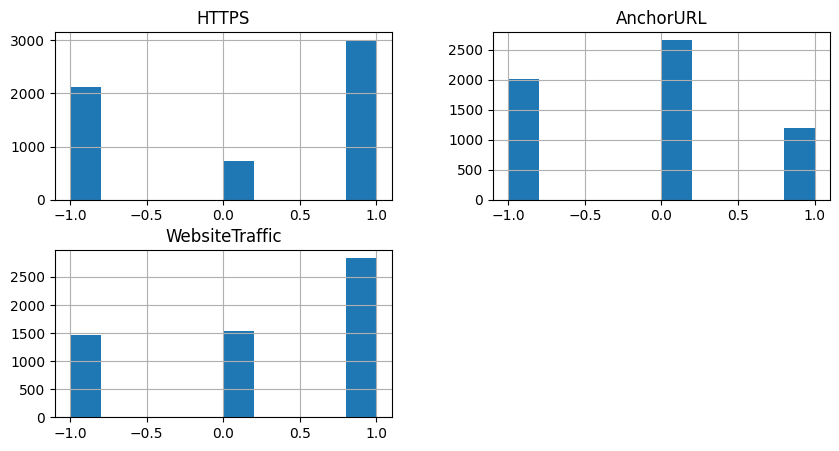

In [43]:
df_no_dup[['HTTPS', 'AnchorURL', 'WebsiteTraffic']].hist(figsize=(10,5))
plt.show()

## Feature Selection

In [24]:
columns_to_drop = [
    'LongURL',
    'ShortURL',
    'Symbol@',
    'Redirecting//',
    'DomainRegLen',
    'Favicon',
    'UsingPopupWindow',
    'IframeRedirection',
    'LinksPointingToPage'
]

df_selected = df_no_dup.drop(columns=columns_to_drop)

print("Shape before feature selection:", df_no_dup.shape)
print("Shape after feature selection:", df_selected.shape)
print("Remaining columns:")
print(df_selected.columns.tolist())

Shape before feature selection: (5849, 31)
Shape after feature selection: (5849, 22)
Remaining columns:
['UsingIP', 'PrefixSuffix-', 'SubDomains', 'HTTPS', 'NonStdPort', 'HTTPSDomainURL', 'RequestURL', 'AnchorURL', 'LinksInScriptTags', 'ServerFormHandler', 'InfoEmail', 'AbnormalURL', 'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick', 'AgeofDomain', 'DNSRecording', 'WebsiteTraffic', 'PageRank', 'GoogleIndex', 'StatsReport', 'class']


## Preparing Features and Target Variable

In [25]:
X = df_selected.drop('class', axis=1)
y = df_selected['class']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (5849, 21)
Target vector shape: (5849,)


## Feature Scaling

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    scaled,
    columns=X.columns
)

print(X_scaled.shape)
X_scaled.head()

(5849, 21)


,UsingIP,PrefixSuffix-,SubDomains,HTTPS,NonStdPort,HTTPSDomainURL,RequestURL,AnchorURL,LinksInScriptTags,ServerFormHandler,...,AbnormalURL,WebsiteForwarding,StatusBarCust,DisableRightClick,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,StatsReport
0,0.874911,-0.369011,-0.082035,0.920511,0.438422,-2.184935,0.885618,0.190783,-1.108454,-0.550407,...,0.437867,-0.389656,0.400932,0.227157,-1.021604,-1.676432,-0.283176,-0.636128,0.451107,0.422518
1,0.874911,-0.369011,-1.328329,-1.243069,0.438422,-2.184935,0.885618,0.190783,-1.108454,-0.550407,...,-2.283797,-0.389656,0.400932,0.227157,0.978852,-1.676432,0.927567,-0.636128,0.451107,-2.366766
2,0.874911,-0.369011,-1.328329,-1.243069,0.438422,-2.184935,-1.129155,0.190783,0.190814,-0.550407,...,0.437867,-0.389656,0.400932,0.227157,-1.021604,-1.676432,0.927567,-0.636128,0.451107,0.422518
3,0.874911,-0.369011,1.164259,0.920511,0.438422,0.457680,0.885618,0.190783,0.190814,-0.550407,...,0.437867,-0.389656,-2.494191,0.227157,-1.021604,-1.676432,-0.283176,-0.636128,0.451107,0.422518
4,-1.142973,-0.369011,1.164259,0.920511,0.438422,-2.184935,0.885618,0.190783,0.190814,-0.550407,...,-2.283797,-0.389656,0.400932,0.227157,0.978852,0.596505,0.927567,-0.636128,0.451107,-2.366766


## Train-Test Split

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4679, 21)
X_test : (1170, 21)
y_train: (4679,)
y_test : (1170,)


## Preserving the Original Training Data

Before applying SMOTE, a copy of the original training dataset was preserved. This allows an additional experiment to be performed later in order to compare model performance with and without oversampling. Such a comparison helps evaluate whether SMOTE provides meaningful benefits for this dataset.

In [28]:
X_train_original = X_train.copy()
y_train_original = y_train.copy()

## Evaluating the Impact of SMOTE

Because the dataset was already relatively balanced after duplicate removal, an additional experiment was conducted to compare model performance with and without SMOTE. This comparison helps determine whether oversampling provided meaningful improvements.

### Gradient Boosting Without SMOTE

To evaluate whether SMOTE provided meaningful benefits, the Gradient Boosting model was also trained using the original training data before oversampling. The results were then compared with the SMOTE-based model.

In [29]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

gb_no_smote = GradientBoostingClassifier(
    max_depth=4,
    learning_rate=0.7,
    random_state=42
)

gb_no_smote.fit(X_train_original, y_train_original)

y_pred_no_smote = gb_no_smote.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_no_smote))
print("Precision:", precision_score(y_test, y_pred_no_smote, pos_label=1))
print("Recall:", recall_score(y_test, y_pred_no_smote, pos_label=1))
print("F1 Score:", f1_score(y_test, y_pred_no_smote, pos_label=1))

Accuracy: 0.9427350427350427
Precision: 0.9338235294117647
Recall: 0.9424860853432282
F1 Score: 0.938134810710988


## Class Balancing with SMOTE

In [30]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=1, random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_original, y_train_original)

print("Training class distribution after SMOTE:")
print(y_train_smote.value_counts())

Training class distribution after SMOTE:
class
-1    2388
 1    2388
Name: count, dtype: int64


In [31]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

gb_no_smote = GradientBoostingClassifier(
    max_depth=4,
    learning_rate=0.7,
    random_state=42
)

gb_no_smote.fit(X_train_original, y_train_original)

y_pred_no_smote = gb_no_smote.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_no_smote))
print("Precision:", precision_score(y_test, y_pred_no_smote, pos_label=1))
print("Recall:", recall_score(y_test, y_pred_no_smote, pos_label=1))
print("F1 Score:", f1_score(y_test, y_pred_no_smote, pos_label=1))

Accuracy: 0.9427350427350427
Precision: 0.9338235294117647
Recall: 0.9424860853432282
F1 Score: 0.938134810710988


## Gradient Boosting Classifier

In [32]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

gb = GradientBoostingClassifier(
    max_depth=4,
    learning_rate=0.7,
    random_state=42
)

gb.fit(X_train_smote, y_train_smote)

y_pred = gb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9461538461538461

Confusion Matrix:
[[597  34]
 [ 29 510]]

Classification Report:
              precision    recall  f1-score   support

          -1       0.95      0.95      0.95       631
           1       0.94      0.95      0.94       539

    accuracy                           0.95      1170
   macro avg       0.95      0.95      0.95      1170
weighted avg       0.95      0.95      0.95      1170



## Error Analysis

To better understand the model's mistakes, false positives and false negatives were examined. False positives correspond to legitimate websites incorrectly classified as phishing, while false negatives correspond to phishing websites incorrectly classified as legitimate. Identifying patterns among these errors can provide insights into the limitations of the selected features and the behavior of the classifier.

In [33]:
# Create a dataframe with predictions
error_df = X_test.copy()

error_df["Actual"] = y_test
error_df["Predicted"] = y_pred

# False Positives
false_positives = error_df[
    (error_df["Actual"] == -1) &
    (error_df["Predicted"] == 1)
]

# False Negatives
false_negatives = error_df[
    (error_df["Actual"] == 1) &
    (error_df["Predicted"] == -1)
]

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

print("\nSample False Positives:")
display(false_positives.head())

print("\nSample False Negatives:")
display(false_negatives.head())

False Positives: 25
False Negatives: 27

Sample False Positives:


,UsingIP,PrefixSuffix-,SubDomains,HTTPS,NonStdPort,HTTPSDomainURL,RequestURL,AnchorURL,LinksInScriptTags,ServerFormHandler,...,StatusBarCust,DisableRightClick,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,StatsReport,Actual,Predicted
807,0.874911,-0.369011,-1.328329,0.920511,-2.280909,0.457680,0.885618,0.190783,0.190814,-0.550407,...,-2.494191,0.227157,0.978852,-1.676432,0.927567,-0.636128,0.451107,-2.366766,-1.0,1
2233,0.874911,-0.369011,1.164259,0.920511,0.438422,0.457680,-1.129155,1.568426,1.490083,2.099249,...,0.400932,0.227157,-1.021604,0.596505,0.927567,1.572010,0.451107,0.422518,-1.0,1
3996,0.874911,-0.369011,1.164259,0.920511,-2.280909,0.457680,0.885618,1.568426,0.190814,0.774421,...,-2.494191,0.227157,0.978852,0.596505,-1.493919,1.572010,0.451107,0.422518,-1.0,1
2764,-1.142973,-0.369011,1.164259,0.920511,0.438422,-2.184935,0.885618,0.190783,0.190814,0.774421,...,0.400932,0.227157,-1.021604,-1.676432,0.927567,-0.636128,-2.216767,0.422518,-1.0,1
805,0.874911,-0.369011,1.164259,0.920511,0.438422,0.457680,0.885618,1.568426,1.490083,-0.550407,...,0.400932,0.227157,0.978852,-1.676432,0.927567,1.572010,0.451107,0.422518,-1.0,1



Sample False Negatives:


,UsingIP,PrefixSuffix-,SubDomains,HTTPS,NonStdPort,HTTPSDomainURL,RequestURL,AnchorURL,LinksInScriptTags,ServerFormHandler,...,StatusBarCust,DisableRightClick,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,StatsReport,Actual,Predicted
2323,-1.142973,-0.369011,-0.082035,0.920511,-2.280909,0.457680,-1.129155,0.190783,-1.108454,-0.550407,...,-2.494191,0.227157,-1.021604,0.596505,-0.283176,1.572010,0.451107,0.422518,1.0,-1
408,0.874911,-0.369011,-1.328329,-1.243069,0.438422,0.457680,0.885618,0.190783,-1.108454,-0.550407,...,0.400932,0.227157,-1.021604,0.596505,-0.283176,-0.636128,-2.216767,0.422518,1.0,-1
5508,0.874911,-0.369011,-1.328329,-1.243069,0.438422,0.457680,0.885618,-1.186860,0.190814,-0.550407,...,0.400932,0.227157,0.978852,0.596505,0.927567,-0.636128,-2.216767,0.422518,1.0,-1
712,-1.142973,-0.369011,-0.082035,-1.243069,-2.280909,-2.184935,-1.129155,-1.186860,1.490083,-0.550407,...,-2.494191,0.227157,-1.021604,-1.676432,-0.283176,-0.636128,0.451107,-2.366766,1.0,-1
132,-1.142973,-0.369011,-1.328329,0.920511,0.438422,-2.184935,-1.129155,0.190783,-1.108454,-0.550407,...,0.400932,0.227157,0.978852,-1.676432,0.927567,-0.636128,0.451107,0.422518,1.0,-1


In [35]:
false_positives.describe().T

,count,mean,std,min,25%,50%,75%,max
UsingIP,25.0,0.390619,0.879575,-1.142973,0.874911,0.874911,0.874911,0.874911
PrefixSuffix-,25.0,0.369938,1.342085,-0.369011,-0.369011,-0.369011,-0.369011,2.709944
SubDomains,25.0,0.266927,1.166911,-1.328329,-1.328329,1.164259,1.164259,1.164259
HTTPS,25.0,0.833967,0.432716,-1.243069,0.920511,0.920511,0.920511,0.920511
NonStdPort,25.0,-0.214218,1.185329,-2.280909,0.438422,0.438422,0.438422,0.438422
HTTPSDomainURL,25.0,0.034861,0.988776,-2.184935,0.457680,0.457680,0.457680,0.457680
RequestURL,25.0,0.321482,0.923285,-1.129155,-1.129155,0.885618,0.885618,0.885618
AnchorURL,25.0,0.852052,0.702463,0.190783,0.190783,0.190783,1.568426,1.568426
LinksInScriptTags,25.0,0.242785,0.954763,-1.108454,0.190814,0.190814,1.490083,1.490083
ServerFormHandler,25.0,0.032517,1.017620,-0.550407,-0.550407,-0.550407,0.774421,2.099249


In [36]:
false_negatives.describe().T

,count,mean,std,min,25%,50%,75%,max
UsingIP,27.0,0.052810,1.010378e+00,-1.142973,-1.142973,0.874911,0.874911,0.874911
PrefixSuffix-,27.0,-0.369011,5.656860e-17,-0.369011,-0.369011,-0.369011,-0.369011,-0.369011
SubDomains,27.0,-0.497466,9.145295e-01,-1.328329,-1.328329,-0.082035,-0.082035,1.164259
HTTPS,27.0,-0.722207,8.145463e-01,-1.243069,-1.243069,-1.243069,-0.161279,0.920511
NonStdPort,27.0,-0.065158,1.076440e+00,-2.280909,0.438422,0.438422,0.438422,0.438422
HTTPSDomainURL,27.0,-0.129568,1.119568e+00,-2.184935,0.457680,0.457680,0.457680,0.457680
RequestURL,27.0,-0.308321,1.008820e+00,-1.129155,-1.129155,-1.129155,0.885618,0.885618
AnchorURL,27.0,-0.625598,6.898020e-01,-1.186860,-1.186860,-1.186860,0.190783,0.190783
LinksInScriptTags,27.0,-0.290396,9.634385e-01,-1.108454,-1.108454,-1.108454,0.190814,1.490083
ServerFormHandler,27.0,-0.354136,7.071408e-01,-0.550407,-0.550407,-0.550407,-0.550407,2.099249


## Feature Importance Analysis
To further investigate which variables contribute most to phishing detection, feature importance scores from the Gradient Boosting model were examined. Higher importance values indicate features that contribute more strongly to the model's predictions.

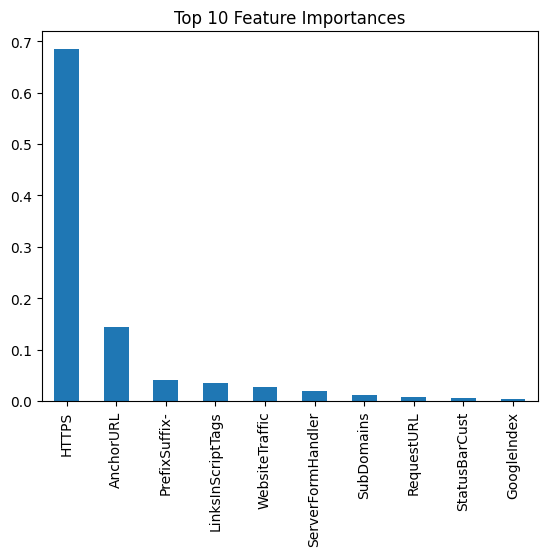

In [ ]:
importance = pd.Series(
    gb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(10).plot(kind="bar")
plt.title("Top 10 Feature Importances")
plt.show()

The feature importance analysis confirmed that features such as HTTPS, AnchorURL, and WebsiteTraffic are among the most influential predictors in the dataset. This result is consistent with the earlier correlation and crosstab analyses, providing additional evidence that these features contain valuable information for distinguishing phishing websites from legitimate websites.

## Model Comparison

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=30, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=10, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(max_depth=4, learning_rate=0.7, random_state=42),
    "Multi-Layer Perceptron": MLPClassifier(random_state=42),
    "Support Vector Machine": SVC()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append([name, accuracy])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

c:\Users\97254\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model,Accuracy
5,Gradient Boosting,0.946154
4,Random Forest,0.939316
6,Multi-Layer Perceptron,0.939316
7,Support Vector Machine,0.938462
0,Logistic Regression,0.923932
3,Decision Tree,0.921368
1,K-Nearest Neighbors,0.917949
2,Naive Bayes,0.661538


## Repeated Split Stability Analysis

To evaluate whether the Gradient Boosting performance was stable across different random train-test splits, the model was trained and evaluated multiple times using different random seeds. This helps determine whether the reported performance is robust or highly dependent on a single split.

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import GradientBoostingClassifier
import pandas as pd

stability_results = []

for seed in range(10):
    X_train_rep, X_test_rep, y_train_rep, y_test_rep = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=seed,
        stratify=y
    )

    gb_rep = GradientBoostingClassifier(
        max_depth=4,
        learning_rate=0.7,
        random_state=42
    )

    gb_rep.fit(X_train_rep, y_train_rep)
    y_pred_rep = gb_rep.predict(X_test_rep)

    stability_results.append({
        "Seed": seed,
        "Accuracy": accuracy_score(y_test_rep, y_pred_rep),
        "Precision": precision_score(y_test_rep, y_pred_rep, pos_label=1),
        "Recall": recall_score(y_test_rep, y_pred_rep, pos_label=1),
        "F1": f1_score(y_test_rep, y_pred_rep, pos_label=1)
    })

stability_df = pd.DataFrame(stability_results)

print(stability_df)
print("\nMean results:")
print(stability_df.drop(columns=["Seed"]).mean())

print("\nStandard deviation:")
print(stability_df.drop(columns=["Seed"]).std())

   Seed  Accuracy  Precision    Recall        F1
0     0  0.943590   0.934028  0.950530  0.942207
1     1  0.934188   0.920826  0.945230  0.932868
2     2  0.936752   0.927083  0.943463  0.935201
3     3  0.947009   0.950000  0.939929  0.944938
4     4  0.922222   0.932605  0.904594  0.918386
5     5  0.943590   0.941696  0.941696  0.941696
6     6  0.936752   0.930070  0.939929  0.934974
7     7  0.942735   0.946333  0.934629  0.940444
8     8  0.946154   0.946714  0.941696  0.944198
9     9  0.946154   0.938918  0.950530  0.944688

Mean results:
Accuracy     0.939915
Precision    0.936827
Recall       0.939223
F1           0.937960
dtype: float64

Standard deviation:
Accuracy     0.007666
Precision    0.009499
Recall       0.013095
F1           0.008142
dtype: float64


### Interpretation

The repeated split experiment produced a mean accuracy of 93.99% with a standard deviation of only 0.77% across ten different train-test splits. Precision, Recall, and F1-score also exhibited relatively small variations.

These results indicate that the performance of the Gradient Boosting model is stable and does not depend heavily on a particular random train-test split. Therefore, the strong performance observed throughout the analysis appears to be robust rather than the result of a favorable partition of the dataset.

## Best Model Evaluation (Gradient Boosting)

In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix
)

y_pred = gb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label=1))
print("Recall:", recall_score(y_test, y_pred, pos_label=1))
print("F1 Score:", f1_score(y_test, y_pred, pos_label=1))
print("MCC:", matthews_corrcoef(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9461538461538461
Precision: 0.9375
Recall: 0.9461966604823747
F1 Score: 0.9418282548476454
MCC: 0.891743845916609

Confusion Matrix:
[[597  34]
 [ 29 510]]


## ROC-AUC Evaluation

ROC-AUC: 0.9915056643605433


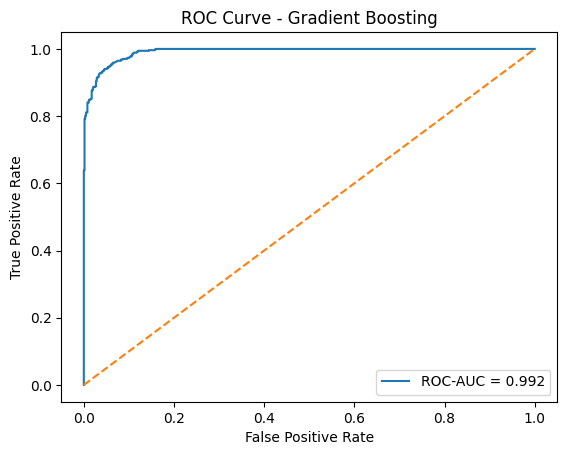

In [38]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_proba = gb.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)

print("ROC-AUC:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_proba, pos_label=1)

plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()
plt.show()

## Additional Evaluation Metrics

Accuracy alone does not fully capture the effectiveness of a phishing detection system. To provide a more comprehensive evaluation, additional metrics were calculated. PR-AUC (Precision-Recall Area Under the Curve) is particularly useful in cybersecurity applications because it focuses on the trade-off between precision and recall. The F2-score places greater emphasis on recall, making it appropriate when failing to detect phishing websites is considered more costly than generating false alarms.

In [39]:
from sklearn.metrics import average_precision_score, fbeta_score

y_prob = gb.predict_proba(X_test)[:, 1]

pr_auc = average_precision_score(y_test, y_prob)

f2 = fbeta_score(
    y_test,
    y_pred,
    beta=2,
    pos_label=1
)

print("PR-AUC:", pr_auc)
print("F2 Score:", f2)

PR-AUC: 0.9901838271782254
F2 Score: 0.9444444444444444
